Saliency Mask

In [ ]:
class SaliencyMask(object):
    def __init__(self, model):
        self.model = model
        self.model.eval()
        self.gradient = None
        self.hooks = list()

    def get_mask(self, image_tensor, target_class=None):
        raise NotImplementedError('A derived class should implemented this method')

    def remove_hooks(self):
        for hook in self.hooks:
            hook.remove()

Vanilla Gradient

In [ ]:
import torch
import numpy as np



class VanillaGradient(SaliencyMask):
    def __init__(self, model):
        super(VanillaGradient, self).__init__(model)

    def get_mask(self, image_tensor, target_class=None):
        image_tensor = image_tensor.clone()
        image_tensor.requires_grad = True
        image_tensor.retain_grad()

        logits = self.model(image_tensor)
        target = torch.zeros_like(logits)
        target[0][target_class if target_class else logits.topk(1, dim=1)[1]] = 1
        self.model.zero_grad()
        logits.backward(target)
        return np.moveaxis(image_tensor.grad.detach().cpu().numpy()[0], 0, -1)

    def get_smoothed_mask(self, image_tensor, target_class=None, samples=25, std=0.15, process=lambda x: x**2):
        std = std * (torch.max(image_tensor) - torch.min(image_tensor)).detach().cpu().numpy()

        batch, channels, width, height = image_tensor.size()
        grad_sum = np.zeros((width, height, channels))
        for sample in range(samples):
            noise = torch.empty(image_tensor.size()).normal_(0, std).to(image_tensor.device)
            noise_image = image_tensor + noise
            grad_sum += process(self.get_mask(noise_image, target_class))
        return grad_sum / samples

    @staticmethod
    def apply_region(mask, region):
        return mask * region[..., np.newaxis]

Integrated Gradient

In [ ]:
import torch
import numpy as np



class IntegratedGradients(VanillaGradient):
    def get_mask(self, image_tensor, target_class=None, baseline='black', steps=25, process=lambda x: x):
        if baseline is 'black':
            baseline = torch.ones_like(image_tensor) * torch.min(image_tensor).detach().cpu()
        elif baseline is 'white':
            baseline = torch.ones_like(image_tensor) * torch.max(image_tensor).detach().cpu()
        else:
            baseline = torch.zeros_like(image_tensor)

        batch, channels, width, height = image_tensor.size()
        grad_sum = np.zeros((width, height, channels))
        image_diff = image_tensor - baseline

        for step, alpha in enumerate(np.linspace(0, 1, steps)):
            image_step = baseline + alpha * image_diff
            grad_sum += process(super(IntegratedGradients, self).get_mask(image_step, target_class))
        return grad_sum * np.moveaxis(image_diff.detach().cpu().numpy()[0], 0, -1) / steps

<>:8: SyntaxWarning: "is" with a literal. Did you mean "=="?
<>:10: SyntaxWarning: "is" with a literal. Did you mean "=="?
<>:8: SyntaxWarning: "is" with a literal. Did you mean "=="?
<>:10: SyntaxWarning: "is" with a literal. Did you mean "=="?
<ipython-input-3-001f5d2b7c56>:8: SyntaxWarning: "is" with a literal. Did you mean "=="?
  if baseline is 'black':
<ipython-input-3-001f5d2b7c56>:10: SyntaxWarning: "is" with a literal. Did you mean "=="?
  elif baseline is 'white':


Utils

In [ ]:
import numpy as np
from matplotlib import pyplot as plt
import colorcet as cc
from PIL import Image
import torchvision


def normalize(mask, vmin=None, vmax=None, percentile=99):
    if vmax is None:
        vmax = np.percentile(mask, percentile)
    if vmin is None:
        vmin = np.min(mask)
    return (mask - vmin) / (vmax - vmin + 1e-10)


def make_grayscale(mask):
    return np.sum(mask, axis=2)


def make_black_white(mask):
    return make_grayscale(np.abs(mask))


def show_mask(mask, title='', cmap=None, alpha=None, norm=True, axis=None):
    if norm:
        mask = normalize(mask)
    (vmin, vmax) = (-1, 1) if cmap == cc.cm.bkr else (0, 1)
    if axis is None:
        plt.imshow(mask, cmap=cmap, alpha=alpha, vmin=vmin, vmax=vmax, interpolation='lanczos')
        if title:
            plt.title(title)
        plt.axis('off')
        plt.tight_layout()
        plt.show()
    else:
        axis.imshow(mask, cmap=cmap, alpha=alpha, vmin=vmin, vmax=vmax, interpolation='lanczos')
        if title:
            axis.set_title(title)
        axis.axis('off')


def cut_image_with_mask(image_path, mask, title='', percentile=70, axis=None):
    image = np.moveaxis(load_image(image_path, size=mask.shape[0], preprocess=False).numpy().squeeze(), 0, -1)
    mask = mask > np.percentile(mask, percentile)
    image[~mask] = 0

    if axis is None:
        plt.imshow(image, interpolation='lanczos')
        if title:
            plt.title(title)
        plt.axis('off')
        plt.tight_layout()
        plt.show()
    else:
        axis.imshow(image, interpolation='lanczos')
        if title:
            axis.set_title(title)
        axis.axis('off')


def show_mask_on_image(image_path, mask, title='', cmap=cc.cm.bmy, alpha=0.7, axis=None):
    image = load_image(image_path, size=mask.shape[0], color_mode='L', preprocess=False).numpy().squeeze()
    if axis is None:
        plt.imshow(image, cmap=cc.cm.gray, interpolation='lanczos')
    else:
        axis.imshow(image, cmap=cc.cm.gray, interpolation='lanczos')
    show_mask(mask, title, cmap, alpha, norm=False, axis=axis)


def pil_loader(path, color_mode='RGB'):
    with open(path, 'rb') as f:
        img = Image.open(f)
        return img.convert(color_mode)


def load_image(path, size=None, color_mode='RGB', preprocess=True):
    pil_image = pil_loader(path, color_mode)
    shape = np.array(pil_image).shape
    transform_list = list()
    if size is not None and size != shape[0]:
        if size < shape[0]:
            if size < 256 < shape[0]:
                transform_list.append(torchvision.transforms.Resize(256))
            transform_list.append(torchvision.transforms.CenterCrop(size))
        else:
            print(f"Warning: Desired size {size} larger than image size {shape[0]}x{shape[1]}. Upscaling.")
            transform_list.append(torchvision.transforms.Resize(size))
    transform_list.append(torchvision.transforms.ToTensor())
    if preprocess:
        transform_list.append(torchvision.transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]))
    transform = torchvision.transforms.Compose(transform_list)
    return transform(pil_image).unsqueeze(0)

Guided Back prop


In [ ]:
import torch



class GuidedBackprop(VanillaGradient):
    def __init__(self, model):
        super(GuidedBackprop, self).__init__(model)
        self.relu_inputs = list()
        self.update_relus()

    def update_relus(self):
        def clip_gradient(module, grad_input, grad_output):
            relu_input = self.relu_inputs.pop()
            return (grad_output[0] * (grad_output[0] > 0.).float() * (relu_input > 0.).float(),)

        def save_input(module, input, output):
            self.relu_inputs.append(input[0])

        for module in self.model.modules():
            if isinstance(module, torch.nn.ReLU):
                self.hooks.append(module.register_forward_hook(save_input))
                self.hooks.append(module.register_backward_hook(clip_gradient))

XRAI

In [ ]:
import numpy as np
from skimage import segmentation
from skimage.transform import resize
from skimage.morphology import disk, dilation



def _normalize_image(im, value_range, resize_shape=None):
    im_max = np.max(im)
    im_min = np.min(im)
    im = (im - im_min) / (im_max - im_min)
    im = im * (value_range[1] - value_range[0]) + value_range[0]
    if resize_shape is not None:
        im = resize(im, resize_shape, order=3, mode='constant', preserve_range=True, anti_aliasing=True)
    return im


def _unpack_segs_to_masks(segs):
    masks = []
    for seg in segs:
        for l in range(seg.min(), seg.max() + 1):
            masks.append(seg == l)
    return masks


def _get_segments_felzenszwalb(image, dilation_rad=5):
    original_shape = image.shape[:2]
    image = _normalize_image(image, value_range=(-1.0, 1.0), resize_shape=(224, 224))
    segs = []
    for scale in [50, 100, 150, 250, 500, 1200]:
        for sigma in [0.8]:
            seg = segmentation.felzenszwalb(image, scale=scale, sigma=sigma, min_size=150)
            seg = resize(seg, original_shape, order=0, preserve_range=True, mode='constant',
                         anti_aliasing=False).astype(np.int)
            segs.append(seg)
    masks = _unpack_segs_to_masks(segs)
    if dilation_rad:
        selem = disk(dilation_rad)
        masks = [dilation(mask, selem=selem) for mask in masks]
    return masks


def _get_diff_mask(add_mask, base_mask):
    return np.logical_and(add_mask, np.logical_not(base_mask))


def _get_diff_cnt(add_mask, base_mask):
    return np.sum(_get_diff_mask(add_mask, base_mask))


def _gain_density(mask1, attr, mask2=None):
    if mask2 is None:
        added_mask = mask1
    else:
        added_mask = _get_diff_mask(mask1, mask2)
    if not np.any(added_mask):
        return -np.inf
    else:
        return attr[added_mask].mean()


def _xrai(attr,
          segs,
          gain_fun=_gain_density,
          area_perc_th=1.0,
          min_pixel_diff=50,
          integer_segments=True):
    output_attr = -np.inf * np.ones(shape=attr.shape, dtype=np.float)

    n_masks = len(segs)
    current_area_perc = 0.0
    current_mask = np.zeros(attr.shape, dtype=bool)

    masks_trace = []
    remaining_masks = {ind: mask for ind, mask in enumerate(segs)}

    added_masks_cnt = 1
    # While the mask area is less than area_th and remaining_masks is not empty
    while current_area_perc <= area_perc_th:
        best_gain = -np.inf
        best_key = None
        remove_key_queue = []
        for mask_key in remaining_masks:
            mask = remaining_masks[mask_key]
            # If mask does not add more than min_pixel_diff to current mask, remove
            mask_pixel_diff = _get_diff_cnt(mask, current_mask)
            if mask_pixel_diff < min_pixel_diff:
                remove_key_queue.append(mask_key)
                continue
            gain = gain_fun(mask, attr, mask2=current_mask)
            if gain > best_gain:
                best_gain = gain
                best_key = mask_key
        for key in remove_key_queue:
            del remaining_masks[key]
        if len(remaining_masks) == 0:
            break
        added_mask = remaining_masks[best_key]
        mask_diff = _get_diff_mask(added_mask, current_mask)
        masks_trace.append((mask_diff, best_gain))

        current_mask = np.logical_or(current_mask, added_mask)
        current_area_perc = np.mean(current_mask)
        output_attr[mask_diff] = best_gain
        del remaining_masks[best_key]  # delete used key
        added_masks_cnt += 1

    uncomputed_mask = output_attr == -np.inf
    # Assign the uncomputed areas a value such that sum is same as ig
    output_attr[uncomputed_mask] = gain_fun(uncomputed_mask, attr)
    masks_trace = [v[0] for v in sorted(masks_trace, key=lambda x: -x[1])]
    if np.any(uncomputed_mask):
        masks_trace.append(uncomputed_mask)
    if integer_segments:
        attr_ranks = np.zeros(shape=attr.shape, dtype=np.int)
        for i, mask in enumerate(masks_trace):
            attr_ranks[mask] = i + 1
        return output_attr, attr_ranks
    else:
        return output_attr, masks_trace


class XRAI(SaliencyMask):
    def __init__(self, model):
        super(XRAI, self).__init__(model)
        self.integrated_gradients = IntegratedGradients(model)

    def get_mask(self, image_tensor, target_class=None, steps=100):
        bbl = self.integrated_gradients.get_mask(image_tensor, target_class, baseline='black', steps=steps)
        wbl = self.integrated_gradients.get_mask(image_tensor, target_class, baseline='white', steps=steps)
        mean_bl = np.mean([bbl, wbl], axis=0)
        baseline = np.max(mean_bl, axis=-1)

        image = np.moveaxis(image_tensor.detach().cpu().numpy()[0], 0, -1)
        segments = _get_segments_felzenszwalb(image)
        attr_map, _ = _xrai(baseline, segments)
        return attr_map

Integrated Gradients

In [ ]:
model = torchvision.models.resnet50(pretrained=True)
# Reload the image as the standard input size for ResNets is 224px.
img = load_image('dog_and_cat.jpeg', size=224)


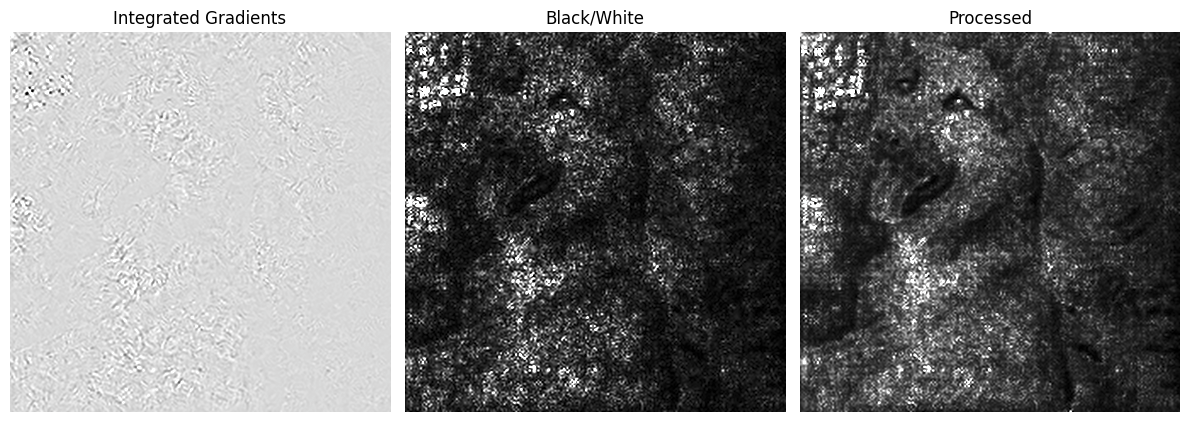

In [ ]:
integrated_gradients = IntegratedGradients(model)
rgb_mask = integrated_gradients.get_mask(image_tensor=img)

# Individual gradients can be processed before being integrated
# by passing a function to the 'process' parameter of the
# 'get_mask' method. By passing e.g. 'np.abs' the visual result
# can be improved.
abs_rgb_mask = integrated_gradients.get_mask(image_tensor=img, process=np.abs)

gray_mask = make_grayscale(rgb_mask)
bw_mask = make_black_white(rgb_mask)
bw_mask_alt = make_black_white(abs_rgb_mask)

figure, axes = plt.subplots(1, 3, figsize=(12, 12), tight_layout=True)
show_mask(gray_mask, title='Integrated Gradients', cmap=cc.cm.gray, axis=axes[0])
show_mask(bw_mask, title='Black/White', cmap=cc.cm.gray, axis=axes[1])
show_mask(bw_mask_alt, title='Processed', cmap=cc.cm.gray, axis=axes[2])


Grad Cam

In [ ]:
from PIL import Image
import numpy as np
import torch



class GradCam(VanillaGradient):
    def __init__(self, model, conv_layer_index=-1):
        super(GradCam, self).__init__(model)

        self.num_conv_layers = self.count_conv_layers()
        self.conv_layer_index = conv_layer_index
        assert abs(self.num_conv_layers) <= self.num_conv_layers, f"Only {self.num_conv_layers} conv layers present"

        self.conv_output = None
        self.register_hooks()

    def count_conv_layers(self):
        num_conv_layers = 0
        for module in self.model.modules():
            if isinstance(module, torch.nn.Conv2d):
                num_conv_layers += 1
        return num_conv_layers

    def register_hooks(self):
        def save_output(module, input, output):
            self.conv_output = output[0]

        def save_gradient(module, grad_input, grad_output):
            if self.gradient is None:
                self.gradient = grad_output[0]

        conv_layer_index = 0
        modules = list(self.model.modules())
        for i, conv in enumerate(reversed(modules)):
            if isinstance(conv, torch.nn.Conv2d):
                conv_layer_index -= 1
                if conv_layer_index == self.conv_layer_index:
                    for relu in modules[-i:]:
                        if isinstance(relu, torch.nn.ReLU):
                            self.hooks.append(relu.register_forward_hook(save_output))
                            self.hooks.append(relu.register_backward_hook(save_gradient))
                            break
                    if self.gradient is None:
                        self.hooks.append(conv.register_forward_hook(save_output))
                        self.hooks.append(conv.register_backward_hook(save_gradient))
                    break

    def get_mask(self, image_tensor, target_class=None, resize=True):
        super(GradCam, self).get_mask(image_tensor, target_class)

        weights = np.mean(self.gradient.detach().cpu().numpy()[0], axis=(1, 2))
        conv_output = np.moveaxis(self.conv_output.detach().cpu().numpy(), 0, -1)

        cam = np.dot(conv_output, weights)
        cam = np.maximum(cam, 0)
        cam /= cam.max()

        if resize:
            cam = np.array(Image.fromarray(cam).resize((image_tensor.shape[2], image_tensor.shape[3]), Image.ANTIALIAS))
        self.gradient = None
        return cam

/usr/local/lib/python3.10/dist-packages/torch/nn/modules/module.py:1344: UserWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  warnings.warn("Using a non-full backward hook when the forward contains multiple autograd Nodes "


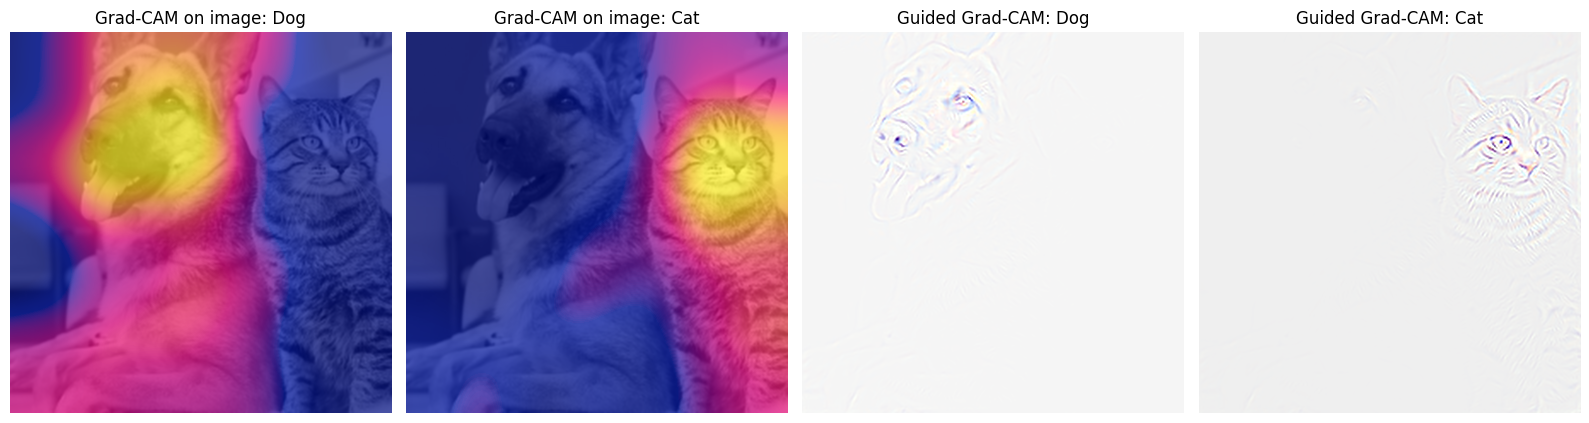

In [ ]:
cat_dog = load_image('dog_and_cat.jpeg', size=224)
class_dog = 235  # Class 'bull mastiff
class_cat = 282  # Class 'tiger cat'
guided_backprop = GuidedBackprop(model)
dog_mask = guided_backprop.get_mask(image_tensor=cat_dog, target_class=class_dog)
cat_mask = guided_backprop.get_mask(image_tensor=cat_dog, target_class=class_cat)
guided_backprop.remove_hooks()

grad_cam = GradCam(model)
dog_region = grad_cam.get_mask(image_tensor=cat_dog, target_class=class_dog)
cat_region = grad_cam.get_mask(image_tensor=cat_dog, target_class=class_cat)
grad_cam.remove_hooks()
guided_grad_cam_dog = guided_backprop.apply_region(dog_mask, dog_region)
guided_grad_cam_cat = guided_backprop.apply_region(cat_mask, cat_region)

figure, axes = plt.subplots(1, 4, figsize=(16, 16), tight_layout=True)
show_mask_on_image(image_path='dog_and_cat.jpeg', mask=dog_region, title='Grad-CAM on image: Dog', axis=axes[0])
show_mask_on_image(image_path='dog_and_cat.jpeg', mask=cat_region, title='Grad-CAM on image: Cat', axis=axes[1])
show_mask(guided_grad_cam_dog, title='Guided Grad-CAM: Dog', axis=axes[2])
show_mask(guided_grad_cam_cat, title='Guided Grad-CAM: Cat', axis=axes[3])

XRAI

In [ ]:
# Yet another model.
model1 = torchvision.models.inception_v3(pretrained=True)
doberman= load_image('doberman.png', size=299)

/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=Inception_V3_Weights.IMAGENET1K_V1`. You can also use `weights=Inception_V3_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


<ipython-input-5-456f8e70a8f1>:34: DeprecationWarning: `np.int` is a deprecated alias for the builtin `int`. To silence this warning, use `int` by itself. Doing this will not modify any behavior and is safe. When replacing `np.int`, you may wish to use e.g. `np.int64` or `np.int32` to specify the precision. If you wish to review your current use, check the release note link for additional information.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  anti_aliasing=False).astype(np.int)
<ipython-input-5-456f8e70a8f1>:39: FutureWarning: `selem` is a deprecated argument name for `dilation`. It will be removed in version 1.0. Please use `footprint` instead.
  masks = [dilation(mask, selem=selem) for mask in masks]
<ipython-input-5-456f8e70a8f1>:68: DeprecationWarning: `np.float` is a deprecated alias for the builtin `float`. To silence this warning, use `float` by itself. Doing this will not modify any behavior and i

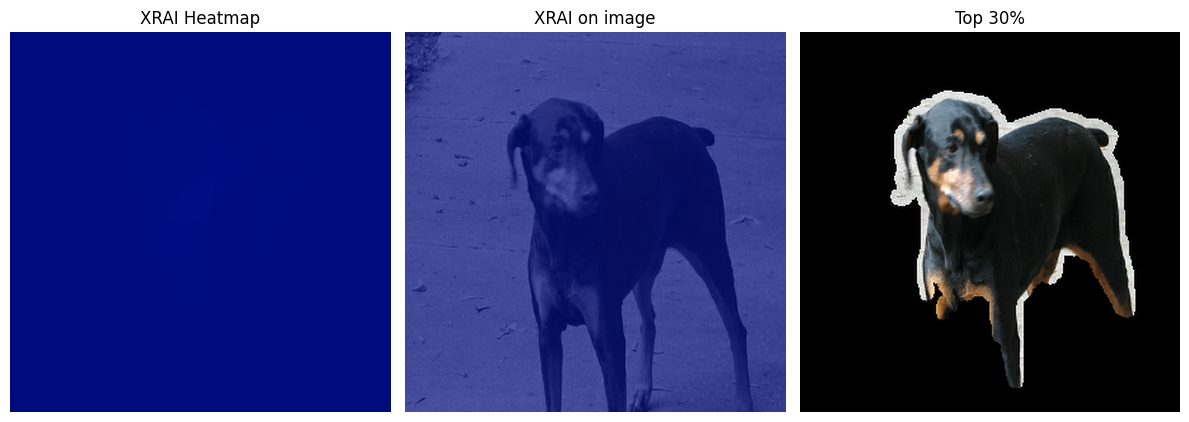

In [ ]:
xrai = XRAI(model1)
segments = xrai.get_mask(image_tensor=doberman)

figure, axes = plt.subplots(1, 3, figsize=(12, 12), tight_layout=True)
show_mask(segments, title='XRAI Heatmap', cmap=cc.cm.bmy, norm=False, axis=axes[0])
show_mask_on_image(image_path='doberman.png', mask=segments, title='XRAI on image', axis=axes[1])
cut_image_with_mask(image_path='doberman.png', mask=segments, title='Top 30%', percentile=70, axis=axes[2])